[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opherdonchin/ModelsOfTheMotorSystems/blob/master/In%20class%20exercises/Ex8_Reinforcement_And_Error.ipynb)

# Lecture 8 In-Class Assignment: Reward and Error Learning (Izawa & Shadmehr, 2011)

A motor command has two kinds of consequence, and therefore two kinds of prediction error:
a **sensory** prediction error (the cursor is not where you predicted) and a **reward**
prediction error (you succeeded or failed). In a visuomotor rotation both could in principle
drive adaptation. We build the Izawa & Shadmehr (2011) optimal-learner model and ask: when does
adaptation run on sensory prediction error, and when does it run on reward prediction error?

You are **given** the parts the lecture treated as the error-based learning system:
- the **system dynamics** (hand, cursor, perturbation, noisy observation), and
- the **state estimation** (a Kalman filter that turns the sensory prediction error into an
  estimate of the perturbation, `p_hat`).

You **build** the rest of the loop — the **control policy** and the **reward learning**:
1. the motor command (the policy),
2. the reward,
3. the reward prediction error (a temporal-difference error against a learned value), and
4. the updates to the reward memory `w_r` and the value `w_v`.

Then you run the model in two conditions and reproduce the lecture result
("Model successfully learns from error or reward").

## Outline
1. [Imports & Setup](#section1)
2. [The perturbation schedule](#section2)
3. [GIVEN: System dynamics](#section3)
4. [GIVEN: State estimation (Kalman filter)](#section4)
5. [Part A — The control policy (motor command)](#section5)
6. [Part B — Reward](#section6)
7. [Part C — Reward prediction error and value](#section7)
8. [Part D — Reward-based policy learning](#section8)
9. [Run both conditions and reproduce the figure](#section9)
10. [Discussion](#section10)

**Instructions**
- Cells marked **DO NOT EDIT** give you the dynamics, the Kalman filter, and the plotting code.
- Cells marked **STUDENT CODE HERE** are where you complete the model.
- Each part has a small **check** cell so you can test a piece before moving on. The checks print
  `[OK]` or `[XX]`; they start as `[XX]` and should read `[OK]` once your code is correct.

<a id="section1"></a>
## 1. Imports & Setup

**DO NOT EDIT**: imports, plotting defaults, model parameters, and a small `check` helper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


def check(name, got, expected):
    """Non-crashing test: print whether `got` matches `expected`."""
    ok = np.allclose(got, expected)
    print(f"[{'OK' if ok else 'XX'}] {name}: got {np.round(got, 4)}, expected {np.round(expected, 4)}")

In [2]:
# ---- Model parameters (shared by BOTH conditions; only s_y differs) ----
a = 1.0           # perturbation persistence in the learner's internal model
s_h = 3.0         # motor (hand) noise, deg
s_p = 0.5         # process noise on the perturbation estimate, deg
s_u = 2.5         # exploration / search noise on the motor command, deg

s_y_by_condition = {   # sensory (cursor) observation noise, deg
    "ERR": 6.0,        #   full visual feedback -> error-based learning is possible
    "RWD": 1e6,        #   no visual feedback   -> only reward is available
}

gamma = 0.95      # reward discount factor
alpha_v = 0.15    # learning rate for the value estimate (critic)
alpha_r = 0.14    # learning rate for the reward memory (actor)
beta = 0.001      # motor-cost weight in the reward
target_radius = 3.0   # cursor within +/- target_radius of the target (at 0) is rewarded

<a id="section2"></a>
## 2. The perturbation schedule

The visuomotor rotation ramps gradually from 0 to -8 degrees (1 degree every 40 trials) and is
then held for a long plateau. A gradual ramp keeps trial-to-trial errors small; this is the
schedule used in the paper.

In [3]:
step_length = 40
num_levels = 9            # rotation values 0, -1, ..., -8 degrees
plateau_length = 140
total_trials = num_levels * step_length + plateau_length

p = np.zeros(total_trials)
t = 0
for level in range(num_levels):
    p[t:t + step_length] = -level
    t += step_length
p[t:] = -(num_levels - 1)

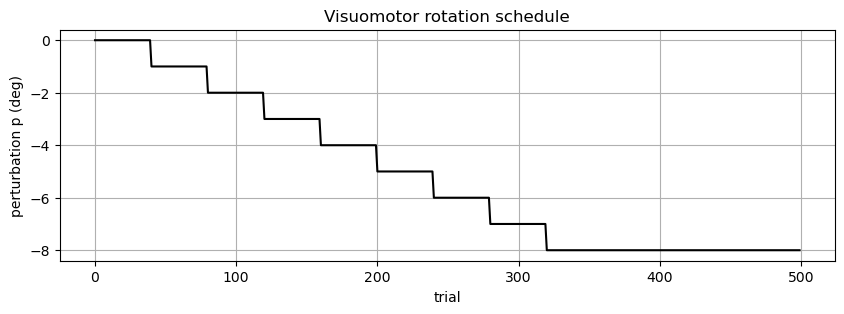

In [4]:
plt.figure(figsize=(10, 3))
plt.plot(p, color="black")
plt.xlabel("trial")
plt.ylabel("perturbation p (deg)")
plt.title("Visuomotor rotation schedule")
plt.show()

<a id="section3"></a>
## 3. GIVEN: System dynamics  (DO NOT EDIT)

On each trial $k$ the hand goes where the motor command sends it, plus motor noise; the cursor is
the hand seen through the rotation $p$; and the brain observes the cursor through sensory noise:

$$ h = u + n_h \qquad c = h + p \qquad y = c + n_y $$

We collect the variables the learner must estimate into a state $x = [\,p,\; h\,]$ with

$$ x_{k+1} = A x_k + b\, u_k + \text{noise}, \qquad y_k = C x_k + n_y, $$
$$ A = \begin{bmatrix} a & 0 \\ 0 & 0 \end{bmatrix}, \quad b = \begin{bmatrix} 0 \\ 1 \end{bmatrix}, \quad C = \begin{bmatrix} 1 & 1 \end{bmatrix}. $$

The first row of $A$ says the perturbation persists ($p_{k+1} = a\,p_k$); the second row plus $b$
say the hand is set by the motor command ($h = u$). $C = [1\ 1]$ says the observed cursor is
$p + h$.

In [5]:
b = np.array([[0.0], [1.0]])
C = np.array([[1.0, 1.0]])


def make_A(a):
    return np.array([[a, 0.0],
                     [0.0, 0.0]])


def true_system_step(u, p_k, n_h_k, n_y_k):
    """Given the motor command and this trial's noise, return (hand, cursor, observation)."""
    h = u + n_h_k
    c = h + p_k
    y = c + n_y_k
    return h, c, y

<a id="section4"></a>
## 4. GIVEN: State estimation — the Kalman filter  (DO NOT EDIT)

This is the error-based learning system from the lecture. It keeps an estimate
$\hat x = [\hat p, \hat h]$ and its uncertainty $P$. Each trial it predicts the cursor, compares
the prediction to the observation to get the **sensory prediction error**, and corrects the
estimate by the Kalman gain $K$:

$$ \text{sensory prediction error} = y - C\hat x^{-}, \qquad
   \hat x = \hat x^{-} + K\,(y - C\hat x^{-}), \qquad
   K = P^{-}C^\top\,(C P^{-} C^\top + \sigma_y^2)^{-1}. $$

The quantity we care about is `p_hat = x_hat[0]`, the brain's estimate of the perturbation. When
sensory noise $\sigma_y$ is small (ERR) the gain is large and `p_hat` tracks `p`; when
$\sigma_y$ is huge (RWD, no feedback) the gain is ~0 and `p_hat` stays at 0.

In [6]:
def kalman_update(x_hat, P, u, y, A, R, Q):
    """One predict/correct step of the Kalman filter. Returns (x_hat_new, P_new, K)."""
    x_pred = A @ x_hat + b * u
    P_pred = A @ P @ A.T + Q
    S = C @ P_pred @ C.T + R
    K = P_pred @ C.T @ np.linalg.inv(S)
    sensory_prediction_error = y - (C @ x_pred)[0, 0]
    x_hat_new = x_pred + K * sensory_prediction_error
    P_new = (np.eye(2) - K @ C) @ P_pred
    return x_hat_new, P_new, K

<a id="section5"></a>
## 5. Part A — The control policy (motor command)

The policy chooses the motor command from the current perturbation estimate `p_hat`, the reward
memory `w_r`, and a little exploration noise `n_u`:

$$ u = -\hat p + w_r + n_u $$

The $-\hat p$ term is the **error-based** correction (cancel the estimated rotation); `w_r` is the
**reward-based** correction you will learn in Parts B–D; `n_u` lets the learner explore.

**Student task**: complete `motor_command` so it returns $-\hat p + w_r + n_u$.

In [7]:
def motor_command(p_hat, w_r, n_u):
    # STUDENT CODE HERE
    # Replace this placeholder, which only uses the error-based term, with the full policy.
    return -p_hat

In [8]:
check("motor_command(p_hat=2, w_r=0, n_u=0)", motor_command(2.0, 0.0, 0.0), -2.0)
check("motor_command(p_hat=2, w_r=3, n_u=0.5)", motor_command(2.0, 3.0, 0.5), 1.5)

[OK] motor_command(p_hat=2, w_r=0, n_u=0): got -2.0, expected -2.0
[XX] motor_command(p_hat=2, w_r=3, n_u=0.5): got -2.0, expected 1.5


**Test the policy with the given Kalman filter (reward learning off).** The helper below is the
trial loop with `w_r` pinned to 0 and no reward learning — pure error-based adaptation. In ERR the
Kalman filter estimates the rotation and your policy cancels it. (This part works as soon as the
error-based term of `motor_command` is in place.)

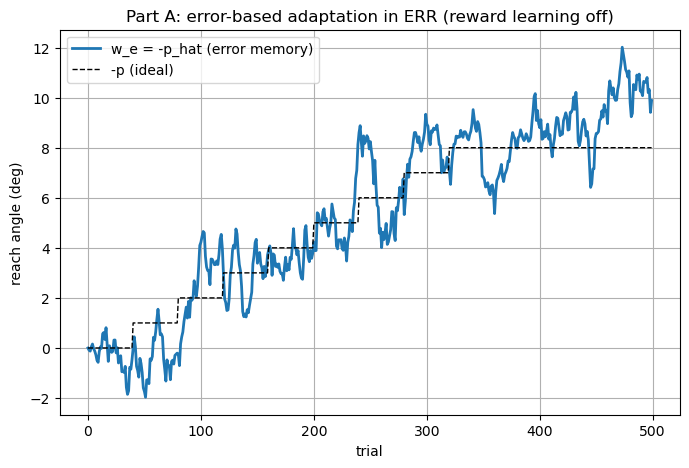

In [9]:
def simulate_error_only(condition, seed=0):
    """Error-based learning only: w_r = 0, no reward updates. (given, to test Part A)"""
    s_y = s_y_by_condition[condition]
    A = make_A(a)
    R = np.array([[s_y ** 2]])
    Q = np.diag([s_p ** 2, s_h ** 2])
    rng = np.random.default_rng(seed)
    n_h = rng.normal(0, s_h, total_trials)
    n_y = rng.normal(0, s_y, total_trials)

    x_hat = np.zeros((2, 1))
    P = Q.copy()
    p_hat = np.zeros(total_trials)
    for k in range(total_trials):
        p_hat[k] = x_hat[0, 0]
        u = motor_command(p_hat[k], 0.0, 0.0)         # w_r = 0, no exploration
        h, c, y = true_system_step(u, p[k], n_h[k], n_y[k])
        x_hat, P, K = kalman_update(x_hat, P, u, y, A, R, Q)
    return p_hat


p_hat_err = simulate_error_only("ERR")
plt.plot(-p_hat_err, color="tab:blue", lw=2, label="w_e = -p_hat (error memory)")
plt.plot(-p, "k--", lw=1, label="-p (ideal)")
plt.xlabel("trial")
plt.ylabel("reach angle (deg)")
plt.title("Part A: error-based adaptation in ERR (reward learning off)")
plt.legend()
plt.show()

**Questions**
- Does `p_hat` track the rotation? Where does it lag?
- If you ran `simulate_error_only("RWD")`, what would `-p_hat` look like, and why?

<a id="section6"></a>
## 6. Part B — Reward

The learner is rewarded when the cursor passes through the target (at 0), minus a small motor cost:

$$ r = \begin{cases} 1 - \beta u^2 & \text{if } |c| < \text{target\_radius (hit)} \\
                        -\beta u^2 & \text{otherwise (miss)} \end{cases} $$

**Student task**: complete `compute_reward`.

In [10]:
def compute_reward(cursor, u):
    # STUDENT CODE HERE
    return 0.0

In [11]:
check("compute_reward(cursor=0, u=0)  [hit, no effort]", compute_reward(0.0, 0.0), 1.0)
check("compute_reward(cursor=10, u=0) [miss, no effort]", compute_reward(10.0, 0.0), 0.0)
check("compute_reward(cursor=0, u=10) [hit, with effort]", compute_reward(0.0, 10.0), 1.0 - beta * 100)

[XX] compute_reward(cursor=0, u=0)  [hit, no effort]: got 0.0, expected 1.0
[OK] compute_reward(cursor=10, u=0) [miss, no effort]: got 0.0, expected 0.0
[XX] compute_reward(cursor=0, u=10) [hit, with effort]: got 0.0, expected 0.9


<a id="section7"></a>
## 7. Part C — Reward prediction error and value

The critic keeps a running value estimate $V = w_v$ of the (discounted) reward it expects. Because
the task state is essentially the same on every trial, the predicted next-state value is also $V$,
so the **reward prediction error** is the temporal-difference error

$$ \delta = r + \gamma V - V $$

and the value is moved to reduce it:

$$ w_v \leftarrow w_v + \alpha_v\, \delta. $$

**Student task**: complete `td_error` (return $\delta$) and `update_value`.

In [12]:
def td_error(r, w_v):
    # STUDENT CODE HERE
    return 0.0


def update_value(w_v, delta):
    # STUDENT CODE HERE
    return w_v

In [13]:
check("td_error(r=1, w_v=0)", td_error(1.0, 0.0), 1.0)
check("td_error(r=1, w_v=4) uses the value baseline", td_error(1.0, 4.0), 1.0 + gamma * 4.0 - 4.0)
check("update_value(w_v=0, delta=1)", update_value(0.0, 1.0), alpha_v)

[XX] td_error(r=1, w_v=0): got 0.0, expected 1.0
[XX] td_error(r=1, w_v=4) uses the value baseline: got 0.0, expected 0.8
[XX] update_value(w_v=0, delta=1): got 0.0, expected 0.15


<a id="section8"></a>
## 8. Part D — Reward-based policy learning (the reward memory `w_r`)

The actor improves the motor command using the reward prediction error and the exploration noise it
actually used on that trial. If a trial's exploration `n_u` happened to raise the reward
($\delta > 0$), shift `w_r` in that direction:

$$ w_r \leftarrow w_r + \alpha_r\, \delta\, n_u. $$

This is **reward-weighted exploration**: it climbs toward better motor commands using only the
scalar reward, with no sensory error signal.

**Student task**: complete `update_reward_memory`.

In [14]:
def update_reward_memory(w_r, delta, n_u):
    # STUDENT CODE HERE
    return w_r

In [15]:
check("positive error + positive exploration raises w_r", update_reward_memory(0.0, 1.0, 2.0), alpha_r * 2.0)
check("positive error + negative exploration lowers w_r", update_reward_memory(0.0, 1.0, -2.0), -alpha_r * 2.0)

[XX] positive error + positive exploration raises w_r: got 0.0, expected 0.28
[XX] positive error + negative exploration lowers w_r: got 0.0, expected -0.28


<a id="section9"></a>
## 9. Run both conditions and reproduce the figure  (simulate loop: DO NOT EDIT)

The loop below wires the GIVEN dynamics and Kalman filter together with the four functions you
built. Read it to see the order of operations on each trial:
choose command → move → observe → reward → reward prediction error → update memories → Kalman update.

Until all four functions are complete the figure will be wrong (in particular RWD will not learn).
When everything is in place, ERR should adapt through the error memory and RWD through the reward
memory.

In [16]:
def simulate(condition, seed=0):
    s_y = s_y_by_condition[condition]
    A = make_A(a)
    R = np.array([[s_y ** 2]])
    Q = np.diag([s_p ** 2, s_h ** 2])
    rng = np.random.default_rng(seed)
    n_h = rng.normal(0, s_h, total_trials)
    n_y = rng.normal(0, s_y, total_trials)
    n_u = rng.normal(0, s_u, total_trials)

    x_hat = np.zeros((2, 1))
    P = Q.copy()
    w_r = 0.0
    w_v = 0.0
    keys = ["p_hat", "w_e", "w_r", "reach", "reward", "delta", "K_p"]
    out = {key: np.zeros(total_trials) for key in keys}

    for k in range(total_trials):
        p_hat = x_hat[0, 0]
        out["p_hat"][k] = p_hat
        out["w_e"][k] = -p_hat          # error memory
        out["w_r"][k] = w_r             # reward memory (value used this trial)

        u = motor_command(p_hat, w_r, n_u[k])
        out["reach"][k] = u

        h, c, y = true_system_step(u, p[k], n_h[k], n_y[k])
        r = compute_reward(c, u)
        out["reward"][k] = r

        delta = td_error(r, w_v)
        out["delta"][k] = delta
        w_v = update_value(w_v, delta)
        w_r = update_reward_memory(w_r, delta, n_u[k])

        x_hat, P, K = kalman_update(x_hat, P, u, y, A, R, Q)
        out["K_p"][k] = K[0, 0]
    return out

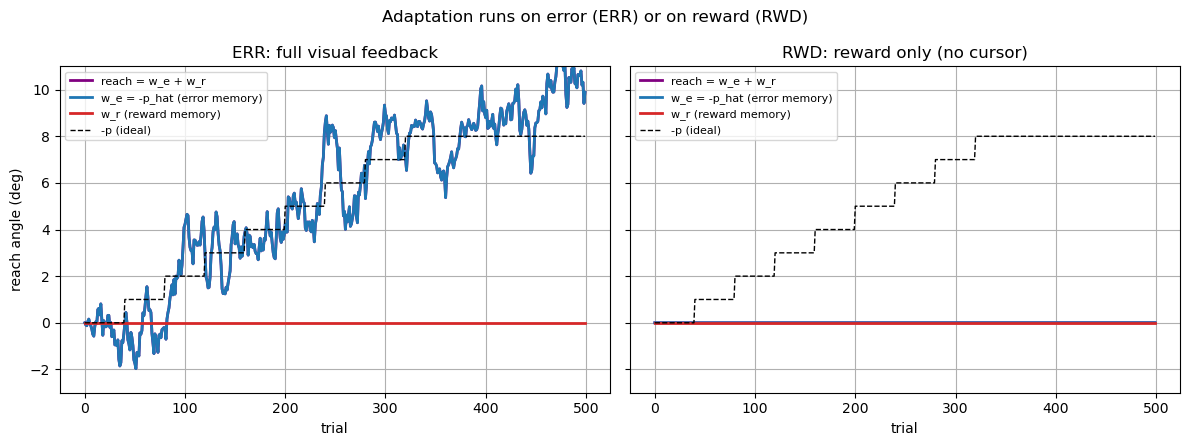

In [17]:
results = {cond: simulate(cond) for cond in ["ERR", "RWD"]}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
titles = {"ERR": "ERR: full visual feedback", "RWD": "RWD: reward only (no cursor)"}
for ax, cond in zip(axes, ["ERR", "RWD"]):
    d = results[cond]
    ax.plot(d["w_e"] + d["w_r"], color="purple", lw=2, label="reach = w_e + w_r")
    ax.plot(d["w_e"], color="tab:blue", lw=2, label="w_e = -p_hat (error memory)")
    ax.plot(d["w_r"], color="tab:red", lw=2, label="w_r (reward memory)")
    ax.plot(-p, "k--", lw=1, label="-p (ideal)")
    ax.set_title(titles[cond])
    ax.set_xlabel("trial")
    ax.set_ylim(-3, 11)
    ax.legend(fontsize=8)
axes[0].set_ylabel("reach angle (deg)")
fig.suptitle("Adaptation runs on error (ERR) or on reward (RWD)")
plt.tight_layout()
plt.show()

**What to look for** (once your four functions are complete)
- In **ERR**, the adaptation is carried by the **error memory** `w_e = -p_hat`, while `w_r` stays
  near 0.
- In **RWD**, the Kalman gain is ~0 so `w_e` stays at 0, and the adaptation is carried entirely by
  the **reward memory** `w_r`.
- The total reach reaches roughly +8 degrees (cancelling the -8 degree rotation) in both cases —
  the same behavior produced by two different learning mechanisms.

<a id="section10"></a>
## 10. Discussion

Please edit this cell to answer:

1. In ERR, which memory (`w_e` or `w_r`) produced the adaptation? In RWD? Why does changing only
   the sensory noise `s_y` switch the model between the two mechanisms?
2. The Kalman gain sets how much the sensory prediction error updates `p_hat`. What is the gain in
   RWD, and why does that force the model to rely on reward?
3. In the paper, only error-based (ERR) adaptation produced a change in the perceived hand position
   (a sensory remapping) and broad generalization. Using the model, explain why reward-based
   learning leaves `p_hat` unchanged.
4. What role does the exploration noise `n_u` play in reward-based learning? What would happen if it
   were zero?
5. The paper links error-based learning to the cerebellum and reward-based learning to the basal
   ganglia. How does that map onto the two update rules in this notebook?